 # Cox Regression and Interaction Analysis

**Authors:** Ali Farzaneh, Akshata Ramachandra

This notebook evaluates associations between circulating microRNAs and incident heart failure using Cox proportional hazards models and assesses effect modification by age and sex.

## Required Libraries

In [1]:
# Libraries
libs <- c(
    'dplyr',
    'purrr',
    'glue',
    'ggplot2',
    'survival',
    'sjPlot',
    'cowplot',
    'grid',
    'gridExtra'
)

suppressPackageStartupMessages(
    invisible(lapply(libs, library, character.only = TRUE))
)

Warning message:
"package 'sjPlot' was built under R version 4.6.1"
Warning message:
"package 'cowplot' was built under R version 4.6.1"
Warning message:
"package 'gridExtra' was built under R version 4.6.1"


### Results directory 

In [2]:
# Directory for analysis outputs
result_dir <- 'results'

if (!dir.exists(result_dir)) {
    dir.create(result_dir, recursive = TRUE)
}

### Functions

In [3]:
## Function to winsorize values outside ±5 SD from the mean

winsorize_5sd <- function(x){
  mean_x <- mean(x, na.rm = TRUE)
  sd_x <- sd(x, na.rm = TRUE)
  
  upper_limit <- mean_x + 5 * sd_x
  lower_limit <- mean_x - 5 * sd_x
  
  x[x > upper_limit] <- upper_limit
  x[x < lower_limit] <- lower_limit
  
  return(x)
}

## Data Loading

### Technical Data

In [4]:
# Load plate and well information used as technical covariates
tech_dat <- readxl::read_excel('data/microRNA_technical_covariates.xlsx') %>%
    mutate(
        Wellcat = case_when(
            grepl('^(A|H)|1$|12$', Well) ~ 'Edge',
            grepl('^(B|G)|2$|11$', Well) ~ 'Middle',
            TRUE ~ 'Center'
        ),
        Wellcat = factor(Wellcat),
        PlateNr = factor(PlateNr)
    )

nrow(tech_dat)

[1] 1999

### microRNA data

In [5]:
# Load the 591 well-expressed miRNAs retained for analysis
miR_dat <- readxl::read_excel(
    'data/591_well_expressed_miRNAs.xlsx'
)

# Replace hyphens in variable names for compatibility with model formulas
colnames(miR_dat) <- gsub('-', '_', colnames(miR_dat))

dim(miR_dat)

[1] 1999

### Clinical and Outcome Data

In [6]:
# Loading clinical covariates and heart failure follow up data
out_dat <- read.csv(
    'data/clinical_outcome_data.csv'
)

nrow(out_dat)

[1] 1999

## Merging datasets

In [7]:
# Merging clinical, technical, and microRNA data
cox_dat <- out_dat %>%
    left_join(tech_dat, by = 'ergoid') %>%
    left_join(miR_dat, by = 'ergoid') 

nrow(cox_dat)

[1] 1999

## Defining microRNAs and Covariates

In [8]:
# microRNAs included in the analysis
microRNAs <- setdiff(colnames(miR_dat), 'ergoid')
length(microRNAs)

# Covariates used in the fully adjusted Cox model
covariates <- c(
    'sex', 'age', 'bmi', 'wbc_c', 'rbc_c', 'eGFR', 'prevalent_dm', 'HT', 'tc', 'hdl', 'smoking', 'lipid_reducing'
)

# Categorical covariates
categorical_covariates <- c(
    'sex', 'prevalent_dm', 'HT', 'smoking', 'lipid_reducing'
)

# Continuous covariates
continuous_covariates <- setdiff(
    covariates,
    categorical_covariates
)

# Technical covariates
technical_covariates <- c(
    'PlateNr', 'Wellcat'
)

# Study cohort used for stratification
stratification_covariates <- 'rs_cohort'

[1] 591

## Preprocessing (Winsorization and Standardization) and defining study population

In [9]:
# Winsorizing continuous variables using the full miRNA-measured population
variables_to_scale <- c(continuous_covariates, microRNAs)

cox_dat <- cox_dat %>%
    mutate(
        across(
            all_of(variables_to_scale),
            ~ winsorize_5sd(.x)
        )
    )

# Defining the study population
cox_dat <- cox_dat %>%
    filter(prevalent_hf == 0) %>%
    select(all_of(c('ergoid', 'obstime_hf', 'incident_hf', covariates, technical_covariates, stratification_covariates, microRNAs )))  


# Standardize within the study population
cox_dat <- cox_dat %>%
    mutate(
        across(
            all_of(variables_to_scale),
            ~ as.numeric(scale(.x))
        )
    )

In [12]:
# dim(cox_dat)
# write.csv( cox_dat, file.path( 'Z:/051379(Ali_Farzaneh)/microRNA/cox_dat.csv'), row.names = FALSE )


## Cox Proportional Hazards Models
### Model 1 – Technical Adjustment  
Model 1 evaluates the association between each microRNA and incident heart failure, adjusting for plate number and well position and stratifying by Rotterdam Study sub-cohort.

In [10]:
# Fitting Model separately for each microRNA
mod1_models <- purrr::map(
    microRNAs,
    ~ suppressWarnings(coxph(
        as.formula(
            paste0(
                'Surv(obstime_hf, incident_hf) ~ ',
                .x,
                ' + Wellcat + PlateNr + strata(rs_cohort)'
            )
        ),
        data = cox_dat
    ) )
)

names(mod1_models) <- microRNAs

In [11]:
# Extracting microRNA effect estimates
mod1_results <- purrr::imap_dfr(
    mod1_models,
    ~ broom::tidy(.x) %>%
        filter(term == .y) %>%
        transmute(
            miRNA = term,
            beta = estimate,
            HR = exp(estimate),
            HR.confint.lower = exp(estimate - 1.96 * std.error),
            HR.confint.upper = exp(estimate + 1.96 * std.error),
            p.value = p.value
        )
) %>%
    mutate(
        adj.p.value = p.adjust(p.value, method = 'BH')
    )

In [12]:
# Nominally significant associations
nominal_mod1_results <- mod1_results %>%
    filter(p.value < 0.05)

# FDR-significant associations
sig_mod1_results <- mod1_results %>%
    filter(adj.p.value < 0.05)

nrow(nominal_mod1_results)
nrow(sig_mod1_results)

[1] 209

[1] 133

In [13]:
head(sig_mod1_results)
write.csv( sig_mod1_results, file.path(result_dir, 'model1_significant_results.csv'), row.names = FALSE )


miRNA,beta,HR,HR.confint.lower,HR.confint.upper,p.value,adj.p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
let_7a_5p,-0.1593399,0.8527065,0.7571065,0.9603779,8.629975e-03,0.0428597933
let_7g_5p,-0.1992603,0.8193366,0.7297464,0.9199256,7.443776e-04,0.0074563926
miR_101_3p,-0.1922091,0.8251344,0.7395733,0.9205940,5.789103e-04,0.0063358511
miR_106a_5p,-0.1589827,0.8530111,0.7602077,0.9571436,6.822957e-03,0.0373367358
miR_106b_3p,-0.1861400,0.8301574,0.7473711,0.9221139,5.149725e-04,0.0057424287
miR_106b_5p,-0.2720155,0.7618424,0.6750485,0.8597959,1.044102e-05,0.0003428135


### Model 2 – Additional Adjustment for Age

Model 2 additionally adjusts for age.

In [14]:
# Fitting Model 2 separately for each microRNA
mod2_models <- purrr::map(
    microRNAs,
    ~ suppressWarnings(coxph(
        as.formula(
            paste0(
                'Surv(obstime_hf, incident_hf) ~ ',
                .x,
                ' + age + Wellcat + PlateNr + strata(rs_cohort)'
            )
        ),
        data = cox_dat
    ) )
)

names(mod2_models) <- microRNAs

In [15]:
# Extractting microRNA effect estimates
mod2_results <- purrr::imap_dfr(
    mod2_models,
    ~ broom::tidy(.x) %>%
        filter(term == .y) %>%
        transmute(
            miRNA = term,
            beta = estimate,
            HR = exp(estimate),
            HR.confint.lower = exp(estimate - 1.96 * std.error),
            HR.confint.upper = exp(estimate + 1.96 * std.error),
            p.value = p.value
        )
) %>%
    mutate(
        adj.p.value = p.adjust(p.value, method = 'BH')
    )

In [16]:
# Nominally significant associations
nominal_mod2_results <- mod2_results %>%
    filter(p.value < 0.05)

# FDR-significant associations
sig_mod2_results <- mod2_results %>%
    filter(adj.p.value < 0.05)

nrow(nominal_mod2_results)
nrow(sig_mod2_results)

[1] 72

[1] 0

In [17]:
write.csv( nominal_mod2_results, file.path(result_dir, 'model2_results.csv'), row.names = FALSE)

### Model 3 – Full Multivariable Adjustment

Model 3 further adjusts for sex, body mass index, white and red blood cell counts, estimated glomerular filtration rate, lipid-lowering medication use, diabetes mellitus, hypertension, total cholesterol, HDL cholesterol, and smoking status.

In [18]:
# Fitting Model 3 separately for each microRNA
mod3_models <- purrr::map(
    microRNAs,
    ~ suppressWarnings(coxph(
        as.formula(
            paste0(
                'Surv(obstime_hf, incident_hf) ~ ',
                .x,
                ' + age + sex + bmi + wbc_c + rbc_c + eGFR + ',
                'lipid_reducing + prevalent_dm + HT + tc + hdl + smoking + ',
                'Wellcat + PlateNr + strata(rs_cohort)'
            )
        ),
        data = cox_dat
    ) )
)

names(mod3_models) <- microRNAs

In [19]:
# Extractting microRNA effect estimates
mod3_results <- purrr::imap_dfr(
    mod3_models,
    ~ broom::tidy(.x) %>%
        filter(term == .y) %>%
        transmute(
            miRNA = term,
            beta = estimate,
            HR = exp(estimate),
            HR.confint.lower = exp(estimate - 1.96 * std.error),
            HR.confint.upper = exp(estimate + 1.96 * std.error),
            p.value = p.value
        )
) %>%
    mutate(
        adj.p.value = p.adjust(p.value, method = 'fdr')
    )

In [20]:
# Nominally significant associations
nominal_mod3_results <- mod3_results %>%
    filter(p.value < 0.05)

# FDR-significant associations
sig_mod3_results <- mod3_results %>%
    filter(adj.p.value < 0.05)

nrow(nominal_mod3_results)
nrow(sig_mod3_results)

[1] 66

[1] 0

In [21]:
write.csv( nominal_mod3_results, file.path(result_dir, 'model3_results.csv'), row.names = FALSE)

### Model 4 – Age-by-microRNA Interaction

In [22]:
# Fit Model 4 separately for each microRNA
mod4_models <- purrr::map(
    microRNAs,
    ~ suppressWarnings(coxph(
        as.formula(
            paste0(
                'Surv(obstime_hf, incident_hf) ~ ',
                'age * ', .x,
                ' + sex + bmi + wbc_c + rbc_c + eGFR + ',
                'lipid_reducing + prevalent_dm + HT + tc + hdl + smoking + ',
                'Wellcat + PlateNr + strata(rs_cohort)'
            )
        ),
        data = cox_dat
    ) )
)

names(mod4_models) <- microRNAs

In [23]:
# Extract microRNA main effects and age-by-microRNA interaction effects
mod4_results <- purrr::imap_dfr(
    mod4_models,
    ~ broom::tidy(.x) %>%
        filter(
            term %in% c(
                .y,
                paste0('age:', .y),
                paste0(.y, ':age')
            )
        ) %>%
        transmute(
            miRNA = term,         
            beta = estimate,
            HR = exp(estimate),
            HR.confint.lower = exp(estimate - 1.96 * std.error),
            HR.confint.upper = exp(estimate + 1.96 * std.error),
            p.value = p.value
        )
) %>%
    mutate(
        adj.p.value = p.adjust(p.value, method = 'fdr')
    )

In [24]:
sig_mod4_results <- mod4_results %>%
    filter(adj.p.value < 0.05)

nrow(sig_mod4_results)

[1] 21

In [25]:
head(sig_mod4_results)
write.csv( sig_mod4_results, file.path(result_dir, 'model4_results.csv'), row.names = FALSE)

miRNA,beta,HR,HR.confint.lower,HR.confint.upper,p.value,Wald.test.pvalue,concordance,adj.p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
age:let_7f_5p,-0.2168527,0.805,0.7190808,0.9012939,1.674119e-04,8.257592e-37,0.7487619,0.028061539
age:let_7i_5p,-0.2337490,0.792,0.7028519,0.8914652,1.159599e-04,1.204119e-35,0.7506461,0.024920836
age:miR_103a_3p,-0.2486160,0.780,0.6983488,0.8709285,1.019435e-05,1.069951e-35,0.7506203,0.008203274
age:miR_107,-0.2471906,0.781,0.6997087,0.8717174,1.041025e-05,1.209939e-35,0.7522574,0.008203274
age:miR_128_3p,-0.2305683,0.794,0.7064609,0.8925711,1.110064e-04,9.722630e-36,0.7548879,0.024920836
age:miR_148a_3p,-0.2286231,0.796,0.7067904,0.8956325,1.538926e-04,4.347510e-37,0.7515881,0.027984784


### Forest Plot of Significant Interactions

In [26]:
# Order miRNAs to match the SHAP figure
shap_order <- c(
    'let-7f-5p',
    'let-7i-5p',
    'miR-103a-3p',
    'miR-107',
    'miR-128-3p',
    'miR-148a-3p',
    'miR-148b-3p',
    'miR-15b-5p',
    'miR-191-5p',
    'miR-199a-3p',
    'miR-199a-5p',
    'miR-20a-5p',
    'miR-20b-5p',
    'miR-21-5p',
    'miR-335-5p',
    'miR-33a-5p',
    'miR-4433b-5p',
    'miR-4655-3p',
    'miR-590-5p',
    'miR-6738-5p',
    'miR-92b-3p'
)

plot_df <- sig_mod4_results %>%
    mutate(
        miRNA = stringr::str_remove(miRNA, '^age:'),
        miRNA_label = gsub('_', '-', miRNA),
        direction = if_else(
            HR < 1,
            'Stronger association at younger ages',
            'Stronger association at older ages'
        ),
        miRNA_label = factor(
            miRNA_label,
            levels = rev(shap_order)
        )
    )

Warning message:
"`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead."
`height` was translated to `width`.


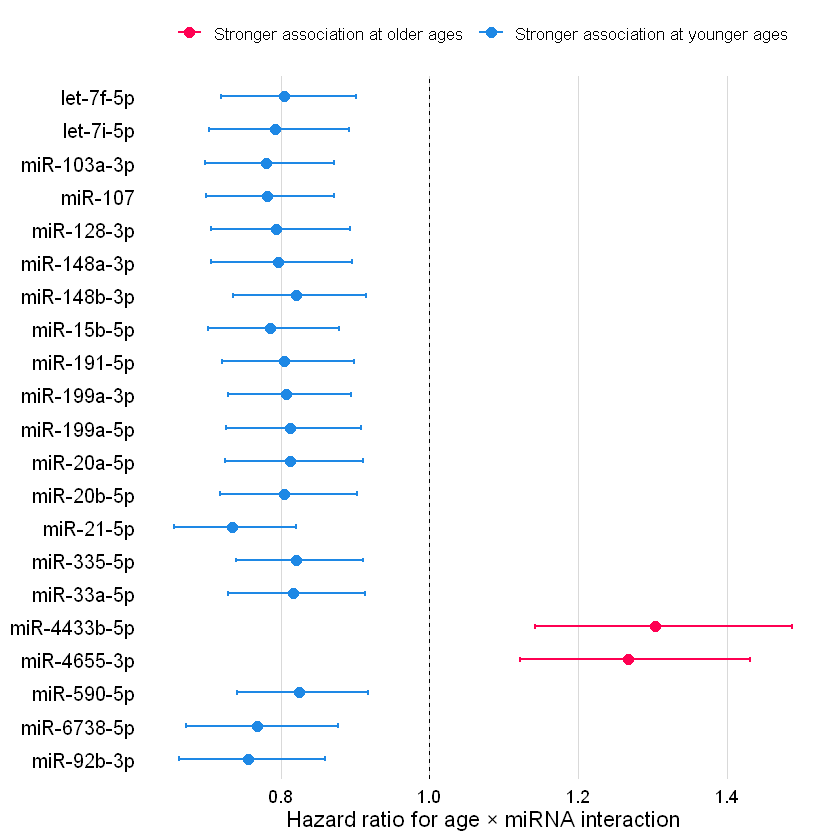

In [27]:
coeff_plot <- ggplot(
    plot_df,
    aes(x = HR, y = miRNA_label, color = direction)
) +
    geom_vline(
        xintercept = 1,
        linetype = 'dashed',
        linewidth = 0.5
    ) +
    geom_errorbarh(
        aes(
            xmin = HR.confint.lower,
            xmax = HR.confint.upper
        ),
        height = 0.15,
        linewidth = 0.6
    ) +
    geom_point(size = 2.6) +
    scale_color_manual(
        values = c(
            'Stronger association at younger ages' = '#1E88E5',
            'Stronger association at older ages' = '#FF0052'
        )
    ) +
    labs(
        x = 'Hazard ratio for age × miRNA interaction',
        y = NULL,
        color = NULL
    ) +
    theme_minimal(base_size = 12) +
    theme(
        axis.text.y = element_text(size = 12, color = 'black'),
        axis.text.x = element_text(size = 11, color = 'black'),
        axis.title.x = element_text(size = 13, color = 'black'),
        legend.position = 'top',
        legend.text = element_text(size = 10),
        panel.grid.major.y = element_blank(),
        panel.grid.minor = element_blank(),
        panel.grid.major.x = element_line(
            color = 'grey85',
            linewidth = 0.4
        ),
        plot.margin = margin(5, 10, 5, 5)
    )

coeff_plot

In [28]:
ggsave(
    filename = file.path(
        result_dir,
        'model4_age_miRNA_interaction_forest_plot.jpeg'
    ),
    plot = coeff_plot,
    width = 6,
    height = 8,
    dpi = 600,
    bg = 'white'
)
ggsave(
    filename = file.path(
        result_dir,
        'model4_age_miRNA_interaction_forest_plot.tiff'
    ),
    plot = coeff_plot,
    device = 'tiff',
    width = 6,
    height = 8,
    units = 'in',
    dpi = 600,
    compression = 'lzw',
    bg = 'white'
)

`height` was translated to `width`.
`height` was translated to `width`.


## Likelihood Ratio Tests
For microRNAs with significant age interactions, nested Cox models with and without the age-by-microRNA interaction term were compared using likelihood ratio tests.

In [29]:
# microRNAs with FDR-significant age interactions
significant_age_miRNAs <- sig_mod4_results$miRNA
significant_age_miRNAs <- stringr::str_remove(significant_age_miRNAs, '^age:')


length(significant_age_miRNAs)


[1] 21

In [30]:
# Null models: no age-by-miRNA interaction
lrt_h0_models <- purrr::map(
    significant_age_miRNAs,
    ~ suppressWarnings(coxph(
        as.formula(
            paste0(
                'Surv(obstime_hf, incident_hf) ~ ',
                .x,
                ' + age + sex + bmi + wbc_c + rbc_c + eGFR + ',
                'lipid_reducing + prevalent_dm + HT + tc + hdl + smoking + ',
                'Wellcat + PlateNr + strata(rs_cohort)'
            )
        ),
        data = cox_dat
    ) )
)

# Alternative models: including age-by-miRNA interaction
lrt_h1_models <- purrr::map(
    significant_age_miRNAs,
    ~ suppressWarnings(coxph(
        as.formula(
            paste0(
                'Surv(obstime_hf, incident_hf) ~ ',
                'age * ', .x,
                ' + sex + bmi + wbc_c + rbc_c + eGFR + ',
                'lipid_reducing + prevalent_dm + HT + tc + hdl + smoking + ',
                'Wellcat + PlateNr + strata(rs_cohort)'
            )
        ),
        data = cox_dat
    ) )
)

names(lrt_h0_models) <- significant_age_miRNAs
names(lrt_h1_models) <- significant_age_miRNAs

In [31]:
lrt_results <- purrr::map2_dfr(
    lrt_h0_models,
    lrt_h1_models,
    ~ {
        lrt <- anova(.x, .y, test = 'LRT')

        tibble(
            loglik_difference = lrt[2, 'loglik'] - lrt[1, 'loglik'],
            p.value = lrt[2, 'Pr(>|Chi|)']
        )
    },
    .id = 'miRNA'
)

In [32]:
lrt_results <- lrt_results %>%
    mutate(
        adj.p.value = p.adjust(p.value, method = 'BH')
    )
lrt_results

miRNA,loglik_difference,p.value,adj.p.value
<chr>,<dbl>,<dbl>,<dbl>
let_7f_5p,6.715819,2.474160e-04,3.711240e-04
let_7i_5p,6.901014,2.031168e-04,3.665401e-04
miR_103a_3p,8.862422,2.552709e-05,1.348422e-04
miR_107,9.006915,2.193058e-05,1.348422e-04
miR_128_3p,7.098988,1.645474e-04,3.665401e-04
miR_148a_3p,6.776428,2.319382e-04,3.711240e-04
miR_148b_3p,5.985928,5.401014e-04,5.969542e-04
miR_15b_5p,8.231286,4.962001e-05,2.084040e-04
miR_191_5p,6.910453,2.010863e-04,3.665401e-04


## Marginal Effect Plots
Marginal interaction plots were generated for the 21 microRNAs with FDR-significant age interactions using the fully adjusted Model 4 Cox models

In [33]:
# Match model names to SHAP order
shap_order_internal <- gsub('-', '_', shap_order)

interaction_models <- mod4_models[shap_order_internal]

In [34]:
inter_plots <- purrr::map2(
    interaction_models,
    shap_order,
    ~ sjPlot::plot_model(
        .x,
        type = 'int',
        terms = c(.y, 'age'),
        title = '',
        axis.title = '',
        auto.label = FALSE,
        legend.title = .y
    ) +
        coord_cartesian(ylim = c(0, 70)) +
        theme_minimal(base_size = 12) +
        theme(
            legend.position = 'bottom',
            legend.title = element_text(
                size = 12,
                face = 'plain',
                color = 'black'
            ),
            legend.text = element_text(
                size = 9,
                color = 'black'
            ),
            axis.title.x = element_blank(),
            axis.title.y = element_blank(),
            axis.text.x = element_text(
                size = 10,
                color = 'black'
            ),
            axis.text.y = element_text(
                size = 10,
                color = 'black'
            ),
            panel.grid.minor = element_blank(),
            panel.grid.major.x = element_line(
                color = 'grey88',
                linewidth = 0.35
            ),
            panel.grid.major.y = element_line(
                color = 'grey92',
                linewidth = 0.30
            ),
            plot.title = element_blank(),
            plot.margin = margin(5, 5, 5, 5)
        )
)

In [35]:
options(
    repr.plot.width = 18,
    repr.plot.height = 12
)

plot_grid_combined <- cowplot::plot_grid(
    plotlist = inter_plots,
    ncol = 6,
    labels = NULL
)

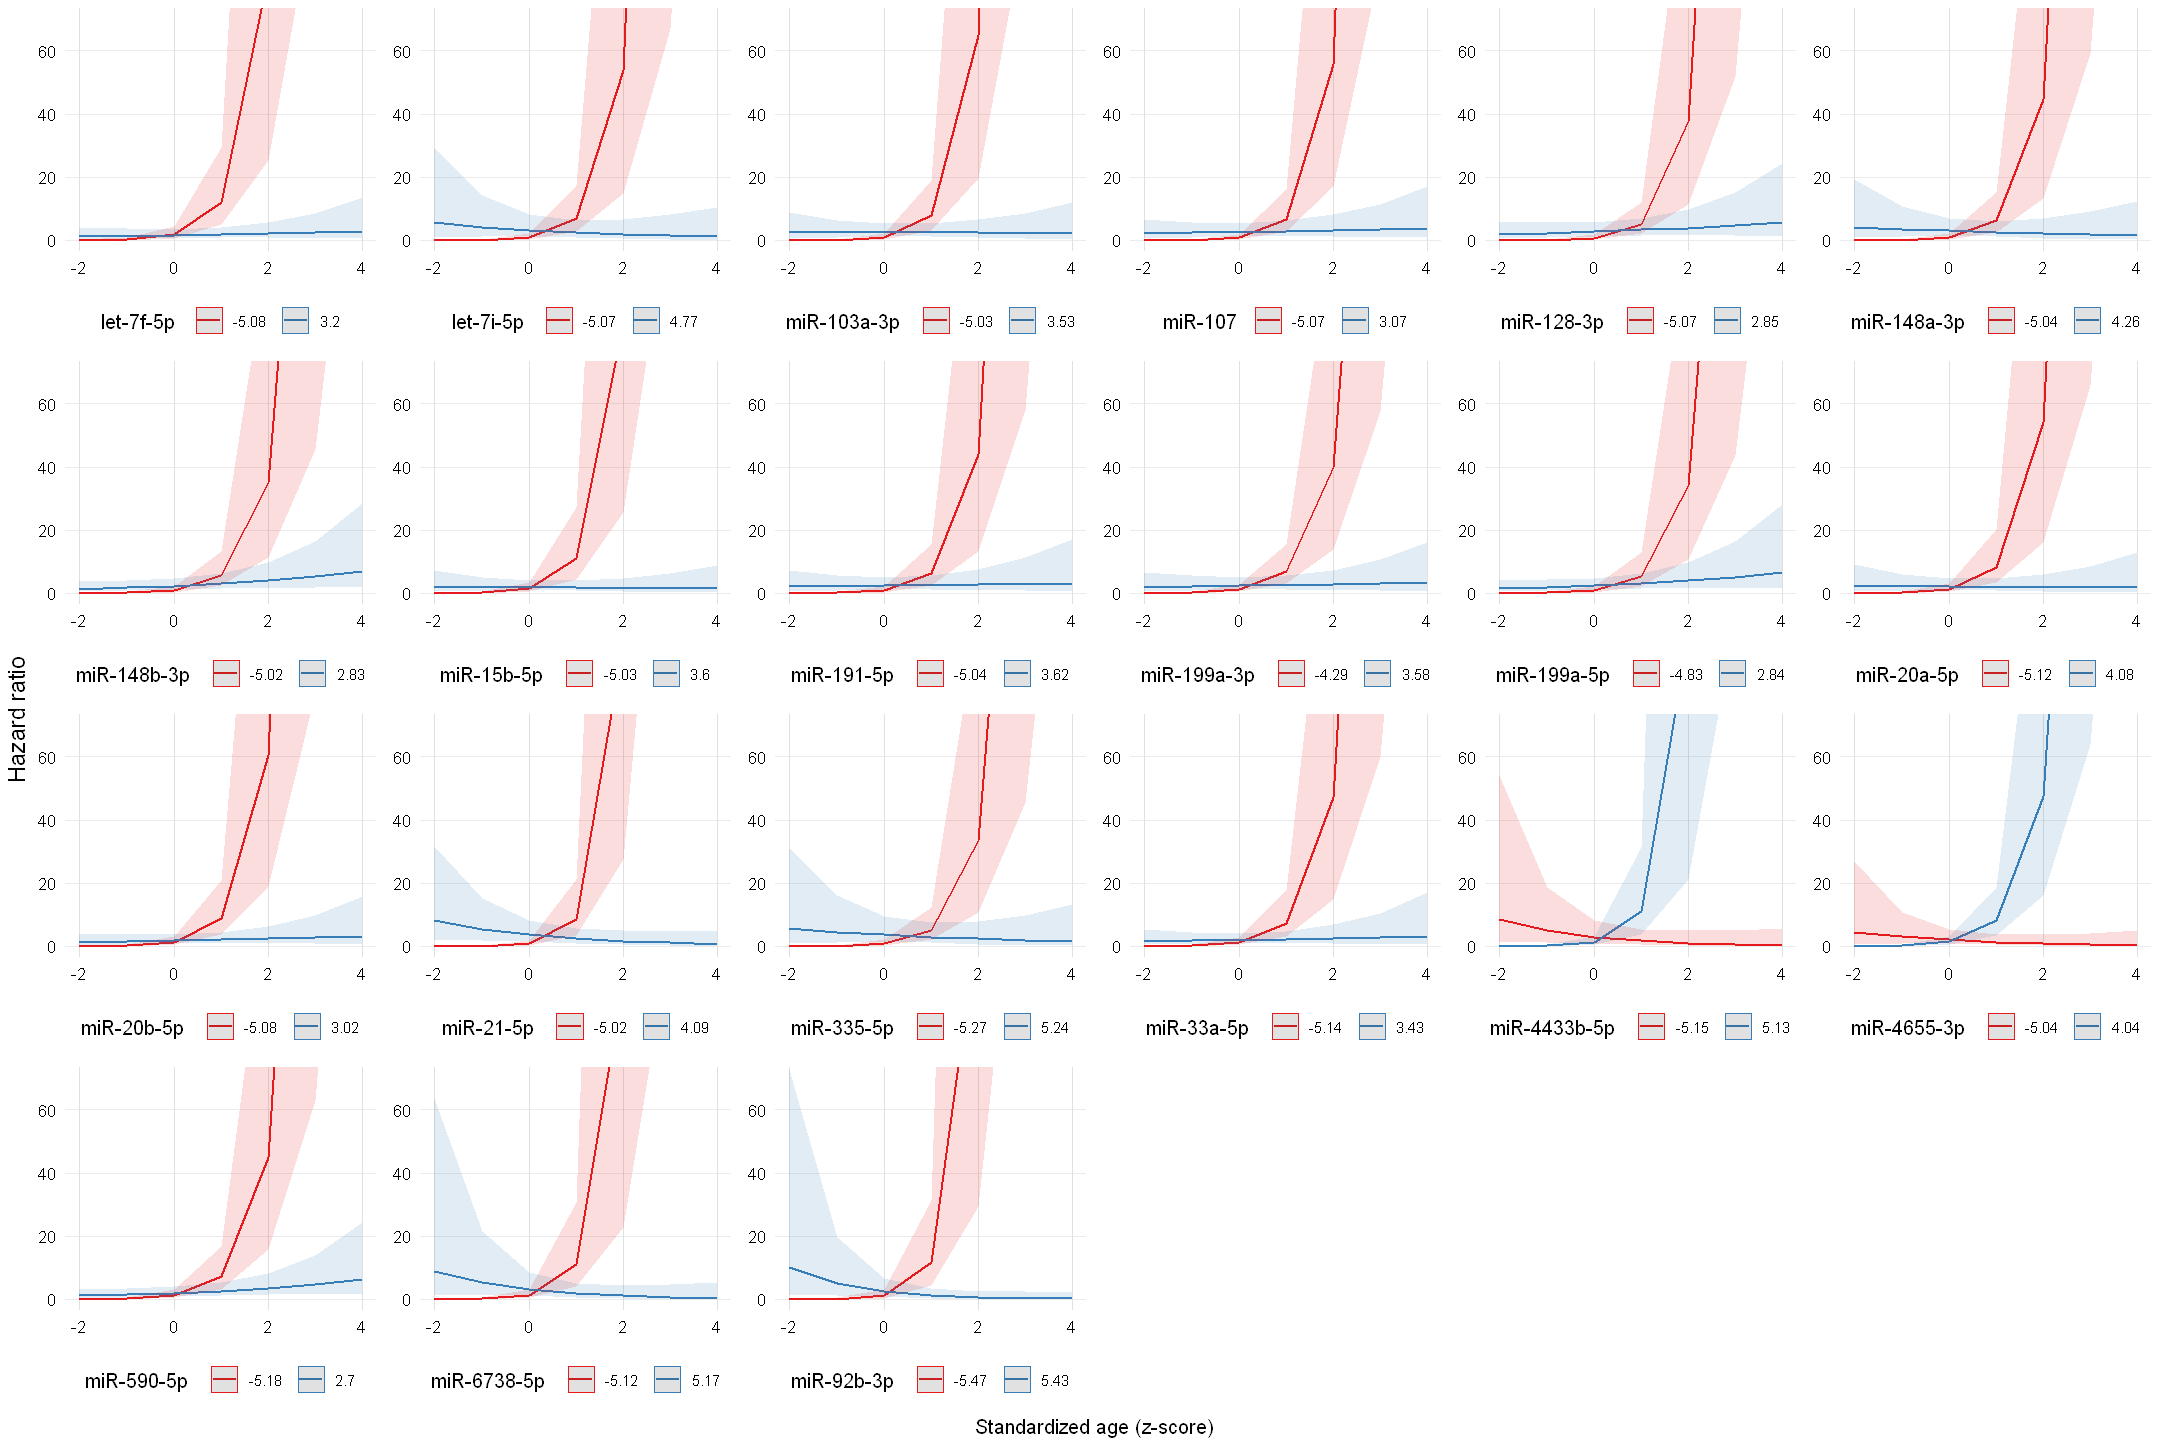

In [36]:
label_x <- grid::textGrob(
    'Standardized age (z-score)',
    gp = grid::gpar(
        col = 'black',
        fontsize = 12
    )
)

label_y <- grid::textGrob(
    'Hazard ratio',
    rot = 90,
    gp = grid::gpar(
        col = 'black',
        fontsize = 14
    )
)

final_interaction_plot <- gridExtra::arrangeGrob(
    plot_grid_combined,
    left = label_y,
    bottom = label_x
)

grid::grid.newpage()
grid::grid.draw(final_interaction_plot)

In [37]:
ggsave(
    filename = file.path(
        result_dir,
        'age_miRNA_interaction_plots.tiff'
    ),
    plot = final_interaction_plot,
    device = 'tiff',
    width = 18,
    height = 12,
    units = 'in',
    dpi = 600,
    compression = 'lzw',
    bg = 'white'
)

 ## Proportional Hazards Assumption
The proportional hazards assumption was assessed using Schoenfeld residuals for the fully adjusted Cox models corresponding to the 21 FDR-significant age-by-microRNA interactions.

In [38]:
# Assess proportional hazards assumption for significant Model 4 interactions
ph_tests <- purrr::imap(
    mod4_models[significant_age_miRNAs],
    ~ survival::cox.zph(.x)
)

In [39]:
ph_results <- purrr::imap_dfr(
    ph_tests,
    ~ {
        test_table <- as.data.frame(.x$table)

        tibble(
            miRNA = .y,
            term = rownames(test_table),
            chisq = test_table$chisq,
            p.value = test_table$p
        )
    }
)

In [40]:
ph_global_results <- ph_results %>%
    filter(term == 'GLOBAL')

ph_global_results

miRNA,term,chisq,p.value
<chr>,<chr>,<dbl>,<dbl>
let_7f_5p,GLOBAL,37.00074,0.6897632
let_7i_5p,GLOBAL,34.64791,0.7824515
miR_103a_3p,GLOBAL,35.32418,0.7571559
miR_107,GLOBAL,35.21596,0.7612851
miR_128_3p,GLOBAL,35.29997,0.7580821
miR_148a_3p,GLOBAL,35.67443,0.7435907
miR_148b_3p,GLOBAL,36.80878,0.6977677
miR_15b_5p,GLOBAL,37.44035,0.6712029
miR_191_5p,GLOBAL,35.37740,0.7551141


In [41]:
ph_violations <- ph_results %>%
    filter(
        term != 'GLOBAL',
        p.value < 0.05
    )

ph_violations

miRNA,term,chisq,p.value
<chr>,<chr>,<dbl>,<dbl>


In [42]:
write.csv(
    ph_results,
    file.path(result_dir, 'proportional_hazards_tests.csv'),
    row.names = FALSE
)

## Sex-by-miRNA Interaction Analysis

In [43]:
cox_dat <- cox_dat %>%
    mutate(
        sex = factor(sex)
    )

In [44]:
# Fit sex-by-microRNA interaction models
sex_int_models <- purrr::map(
    microRNAs,
    ~ suppressWarnings(coxph(
        as.formula(
            paste0(
                'Surv(obstime_hf, incident_hf) ~ ',
                'sex * ', .x,
                ' + age + bmi + wbc_c + rbc_c + eGFR + ',
                'lipid_reducing + prevalent_dm + HT + tc + hdl + smoking + ',
                'Wellcat + PlateNr + strata(rs_cohort)'
            )
        ),
        data = cox_dat
    ))
)

names(sex_int_models) <- microRNAs

In [45]:
sex_int_results <- purrr::imap_dfr(
    sex_int_models,
    ~ broom::tidy(.x) %>%
    
        filter(
            term %in% c(
                .y,
                paste0('sex:', .y),
                paste0(.y, ':sex')
            )
        ) %>% 
        transmute(
            miRNA = .y,
            term = term,
            beta = estimate,
            HR = exp(estimate),
            HR.confint.lower = exp(estimate - 1.96 * std.error),
            HR.confint.upper = exp(estimate + 1.96 * std.error),
            p.value = p.value
        )
) %>%
    mutate(
        adj.p.value = p.adjust(p.value, method = 'BH')
    )

In [46]:
# Nominally significant sex interactions
nominal_sex_int_results <- sex_int_results %>%
    filter(p.value < 0.05)

# FDR-significant sex interactions
sig_sex_int_results <- sex_int_results %>%
    filter(adj.p.value < 0.05)

nrow(nominal_sex_int_results)
nrow(sig_sex_int_results)

[1] 30

[1] 0

In [47]:
write.csv(
    nominal_sex_int_results,
    file.path(result_dir, 'sex_miRNA_interaction_results.csv'),
    row.names = FALSE
)

## Session Information

In [48]:
sessionInfo()

R version 4.6.0 (2026-04-24 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_United States.utf8 
[2] LC_CTYPE=English_United States.utf8   
[3] LC_MONETARY=English_United States.utf8
[4] LC_NUMERIC=C                          
[5] LC_TIME=English_United States.utf8    

time zone: Europe/Berlin
tzcode source: internal

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
[1] gridExtra_2.3.1 cowplot_1.2.0   sjPlot_2.9.0    survival_3.8-6 
[5] ggplot2_4.0.3   glue_1.8.1      purrr_1.2.2     dplyr_1.2.1    

loaded via a namespace (and not attached):
 [1] generics_0.1.4     tidyr_1.3.2        stringi_1.8.7      lattice_0.22-9    
 [5] hms_1.1.4          digest_0.6.39      magrittr_2.0.5     evaluate_1.0.5    
 [9] RColorBrewer_1.1-3 pbdZMQ_0.3-14      fastmap_1.2.0      cellranger_1.1.0  
[13